In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
df = pd.read_csv("processed_data.csv")

In [3]:
# class distribution

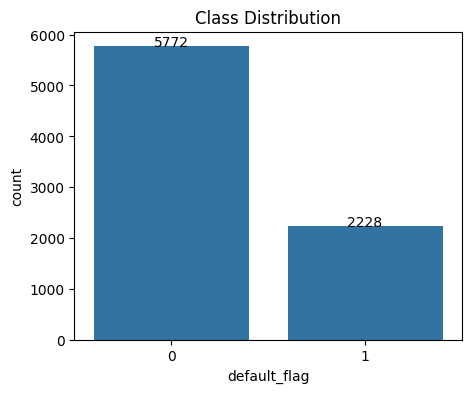

In [4]:
plt.figure(figsize=(5,4))
sns.countplot(data=df, x="default_flag")

for p in plt.gca().patches:
    plt.text(p.get_x() + p.get_width()/2,
             p.get_height(),
             int(p.get_height()),
             ha='center')

plt.title("Class Distribution")
plt.show()

In [5]:
# 2. Correlation Heatmap (numeric)

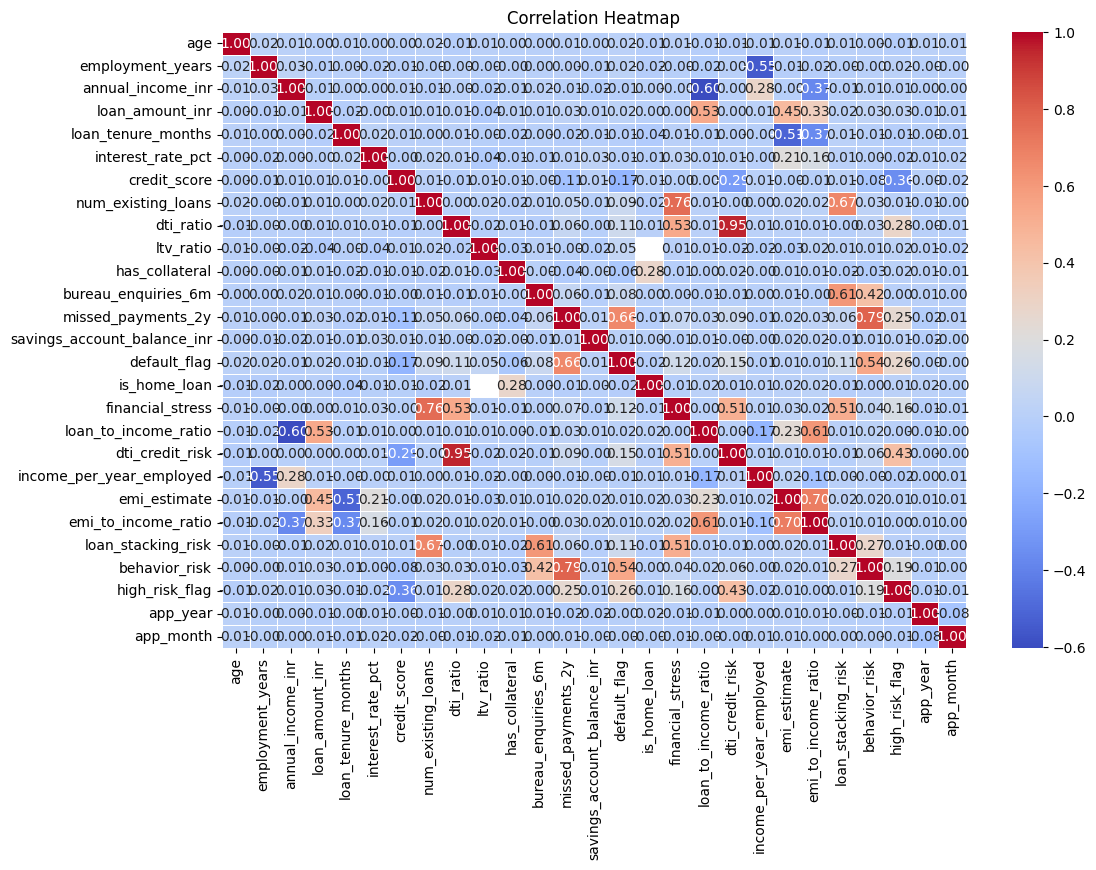

In [6]:
num_df = df.select_dtypes(include='number')

plt.figure(figsize=(12,8))
corr = num_df.corr()

sns.heatmap(corr, annot=True, fmt = "0.2f", cmap = "coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

In [7]:
# 3. Default Rate by Categorical Features (Subplots)

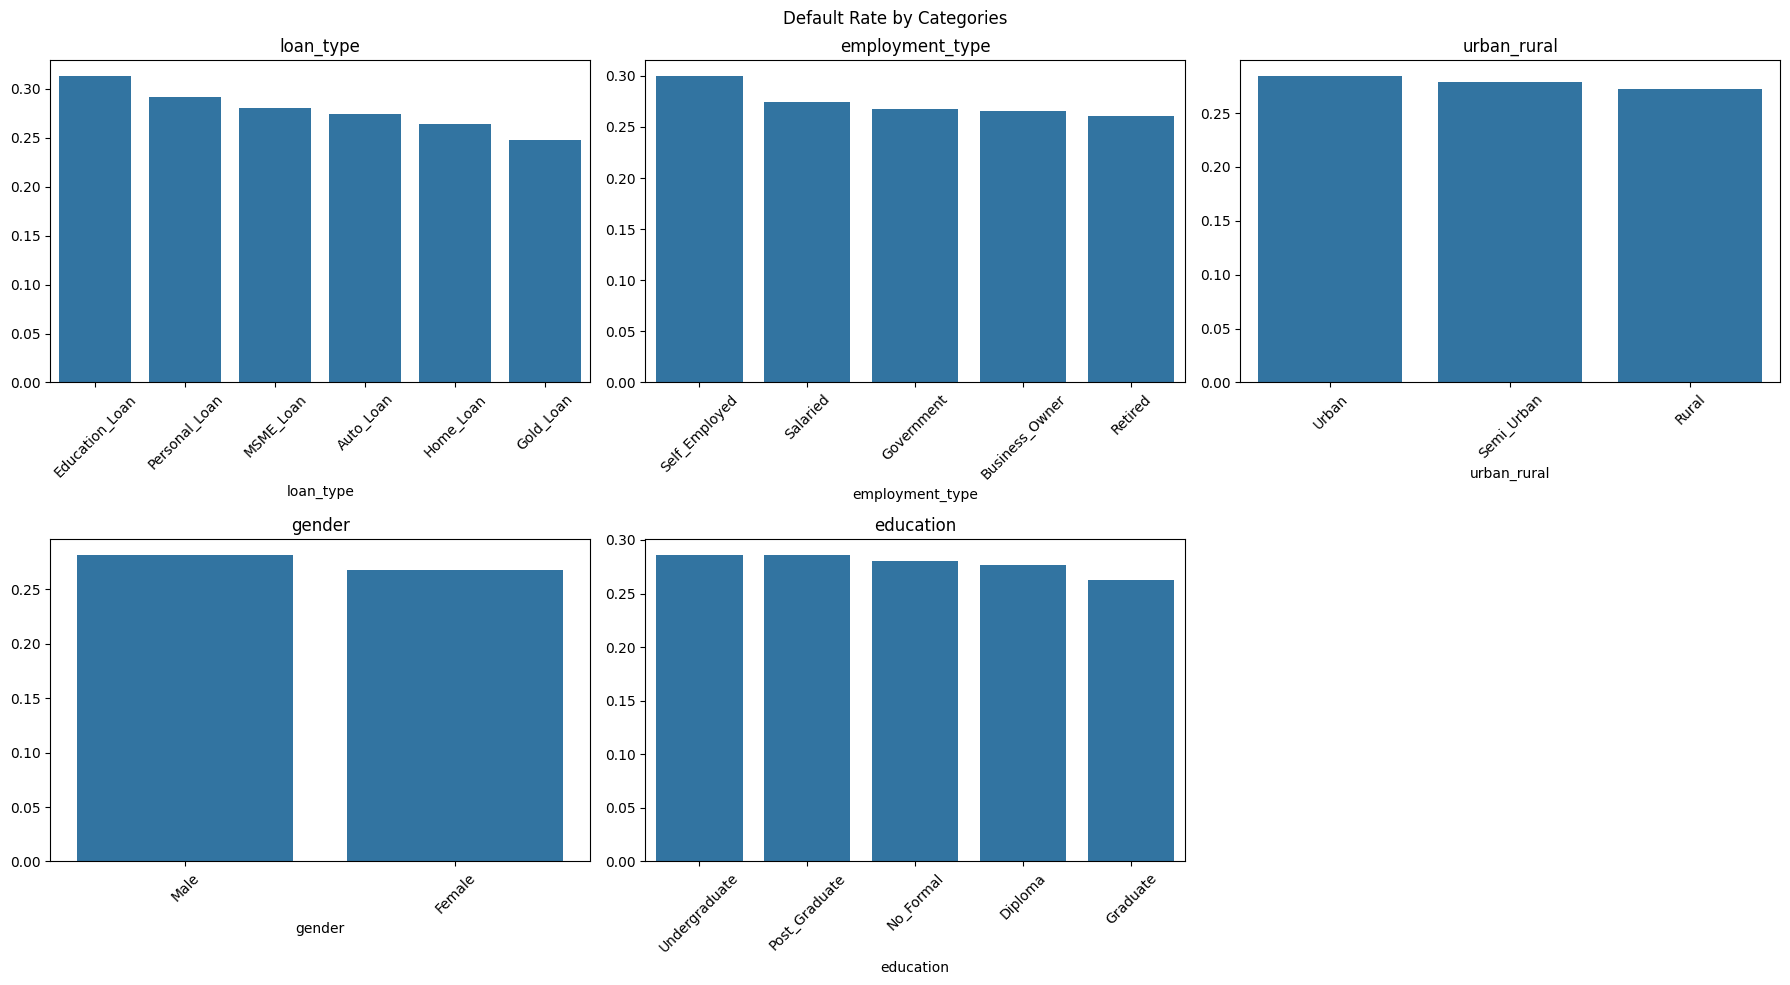

In [8]:
cat_cols = ["loan_type", "employment_type", "urban_rural", "gender", "education"]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    rate = df.groupby(col)["default_flag"].mean().sort_values(ascending=False)
    
    sns.barplot(x=rate.index, y=rate.values, ax=axes[i])
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=45)

fig.delaxes(axes[-1])
plt.suptitle("Default Rate by Categories")
plt.tight_layout()
plt.show()

In [9]:
# 4. Distribution Plots

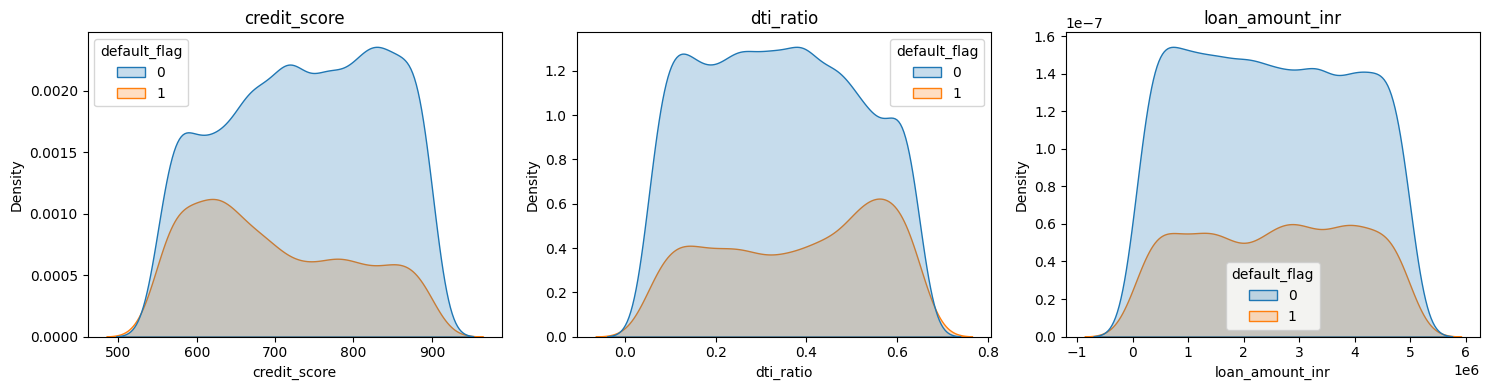

In [10]:
features = ["credit_score", "dti_ratio", "loan_amount_inr"]

plt.figure(figsize=(15,4))

for i, col in enumerate(features):
    plt.subplot(1,3,i+1)
    sns.kdeplot(data=df, x=col, hue="default_flag", fill=True)
    plt.title(col)

plt.tight_layout()
plt.show()

In [11]:
# 5. Boxplots

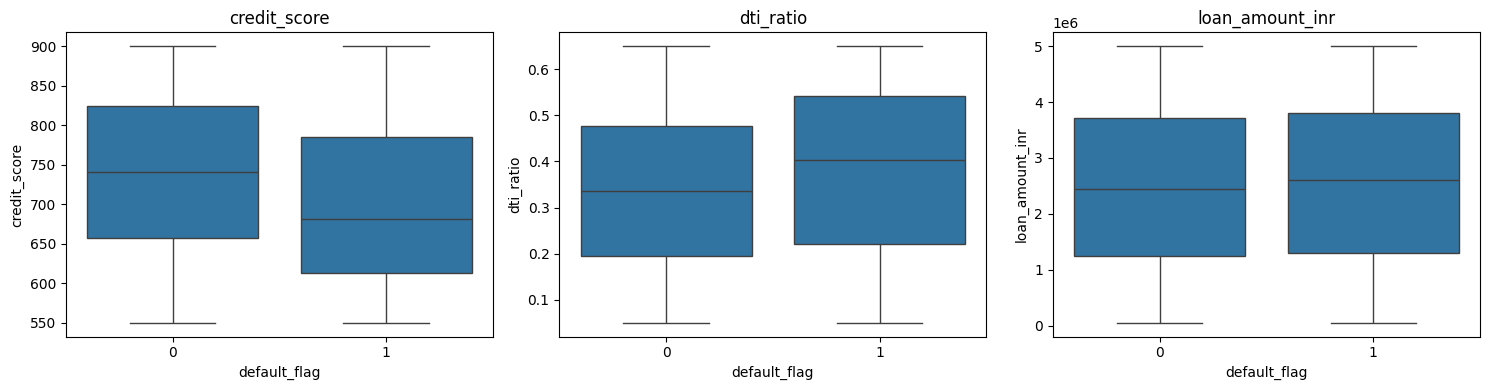

In [12]:
plt.figure(figsize=(15,4))

for i, col in enumerate(features):
    plt.subplot(1,3,i+1)
    sns.boxplot(data=df, x="default_flag", y=col)
    plt.title(col)

plt.tight_layout()
plt.show()

In [13]:
# 6. Skewness Visualization

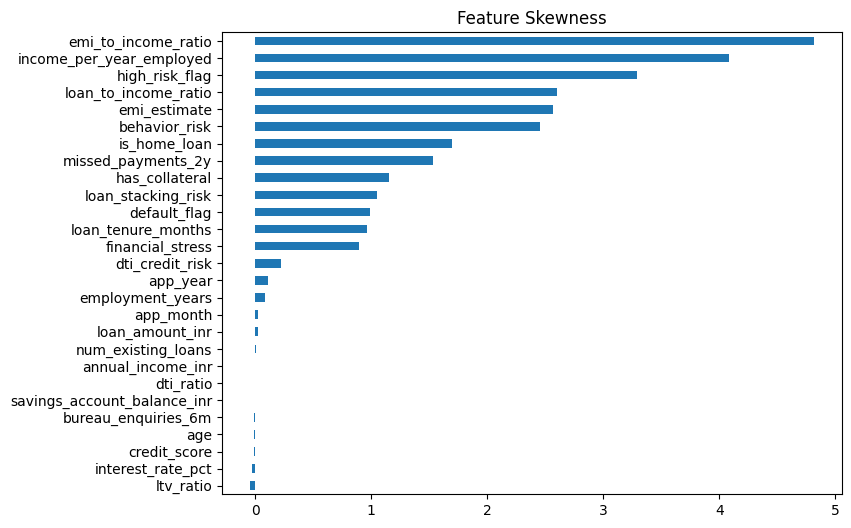

In [14]:
skew_vals = num_df.skew().sort_values()

plt.figure(figsize=(8,6))
skew_vals.plot(kind="barh")
plt.title("Feature Skewness")
plt.show()

In [15]:
# 7. Outlier Visualization

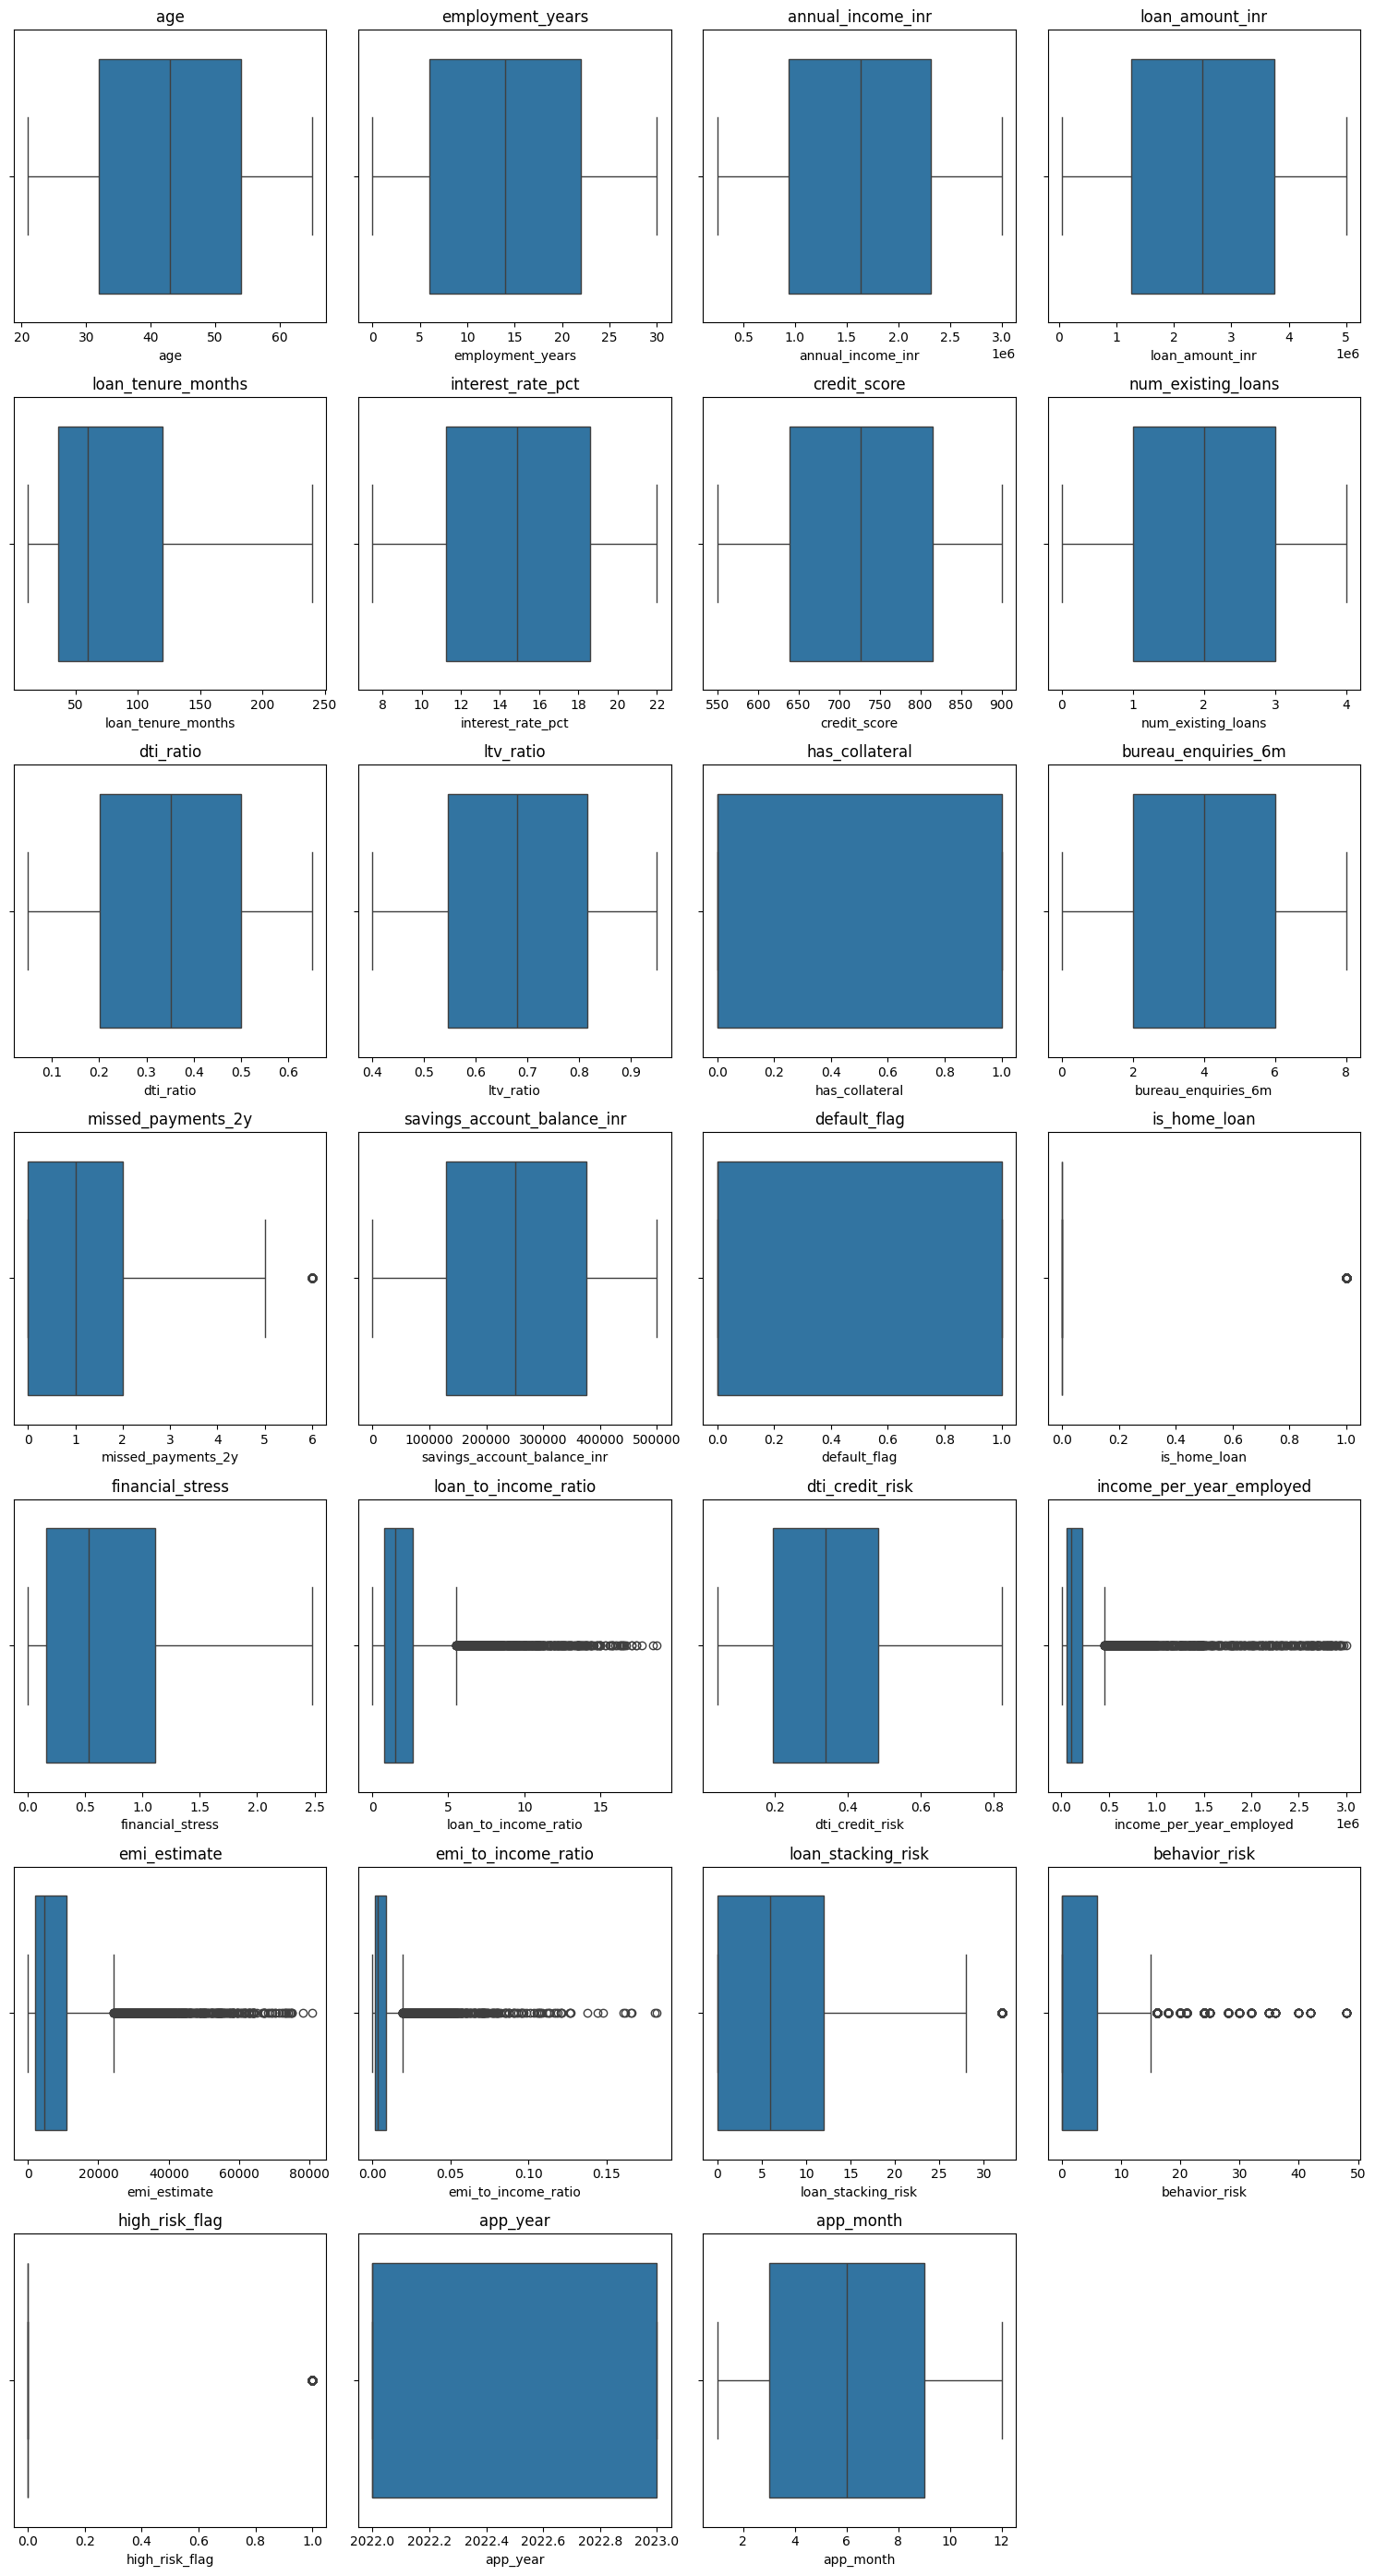

In [16]:
numeric_cols = num_df.columns

n_cols = 4
n_rows = (len(numeric_cols) + n_cols - 1)//n_cols

plt.figure(figsize=(15, 4*n_rows))

for i, col in enumerate(numeric_cols):
    plt.subplot(n_rows, n_cols, i+1)
    sns.boxplot(x=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [17]:
# 8. Engineered Feature Distributions

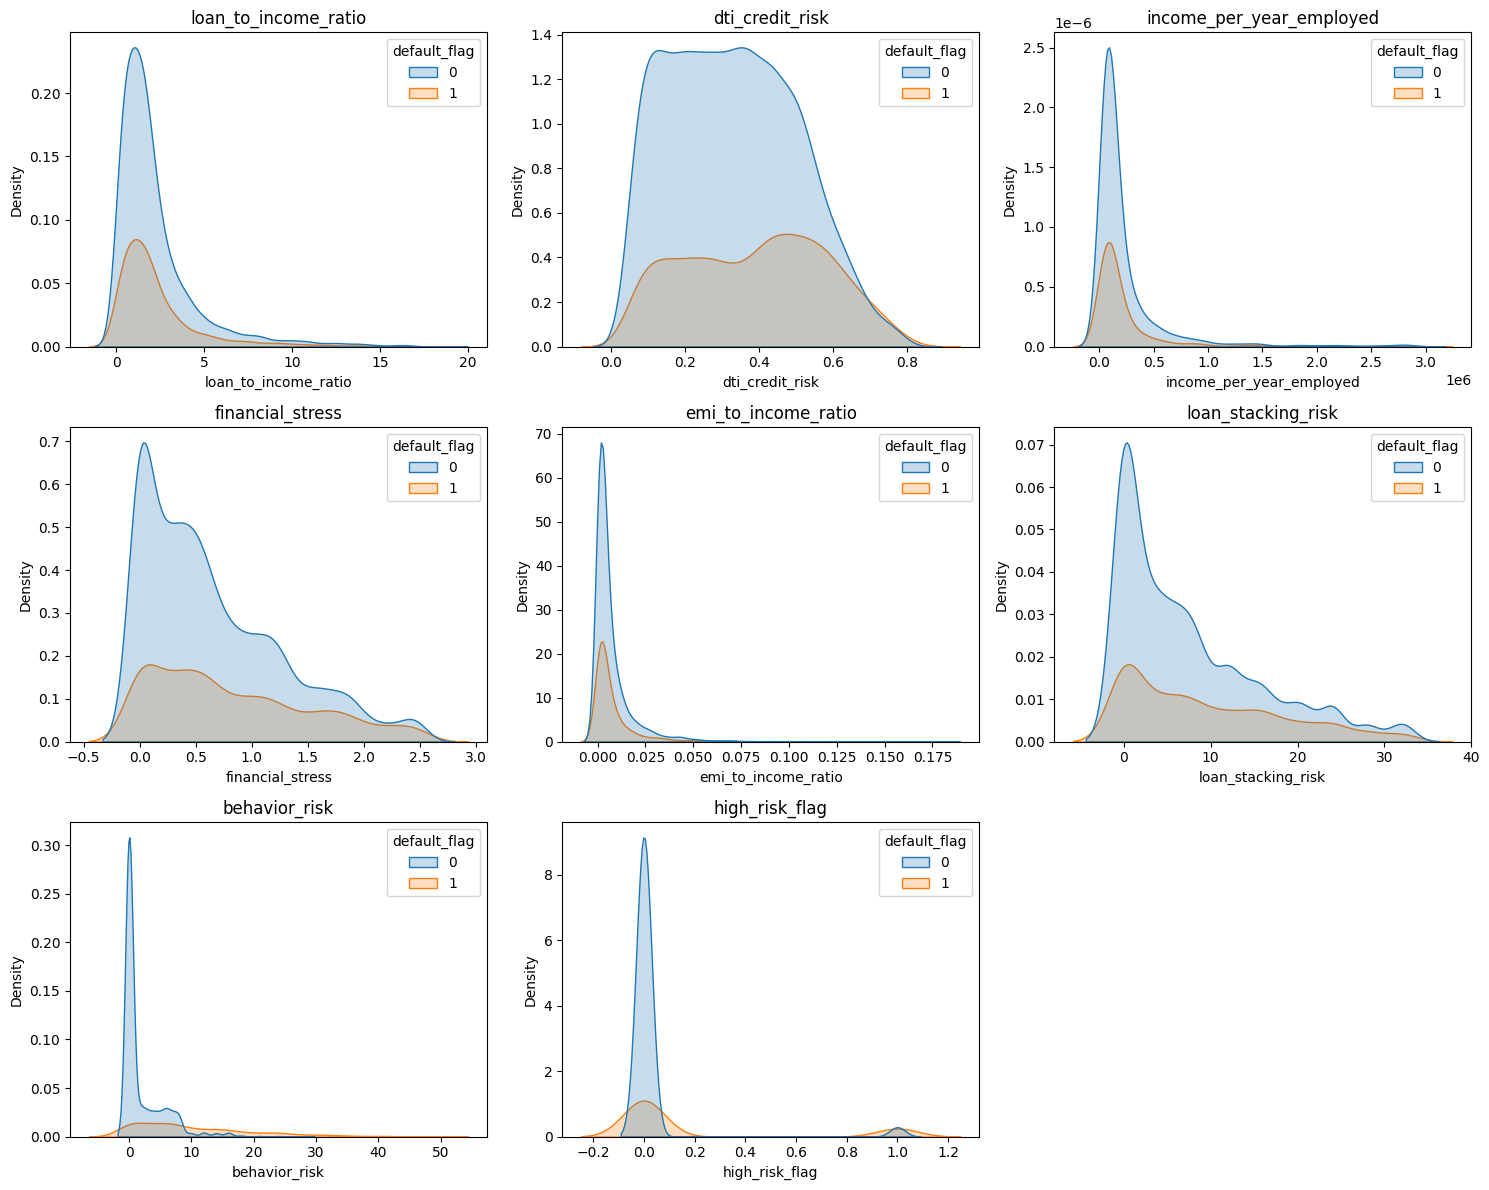

In [18]:
new_features = [
    "loan_to_income_ratio",
    "dti_credit_risk",
    "income_per_year_employed",
    "financial_stress",
    "emi_to_income_ratio",
    "loan_stacking_risk",
    "behavior_risk",
    "high_risk_flag"
]

n_cols = 3
n_rows = (len(new_features) + n_cols - 1) // n_cols

plt.figure(figsize=(15, 4*n_rows))

for i, col in enumerate(new_features):
    plt.subplot(n_rows, n_cols, i+1)
    sns.kdeplot(data=df, x=col, hue="default_flag", fill=True)
    plt.title(col)

plt.tight_layout()
plt.show()

In [19]:
# 9. Engineered Features vs Target

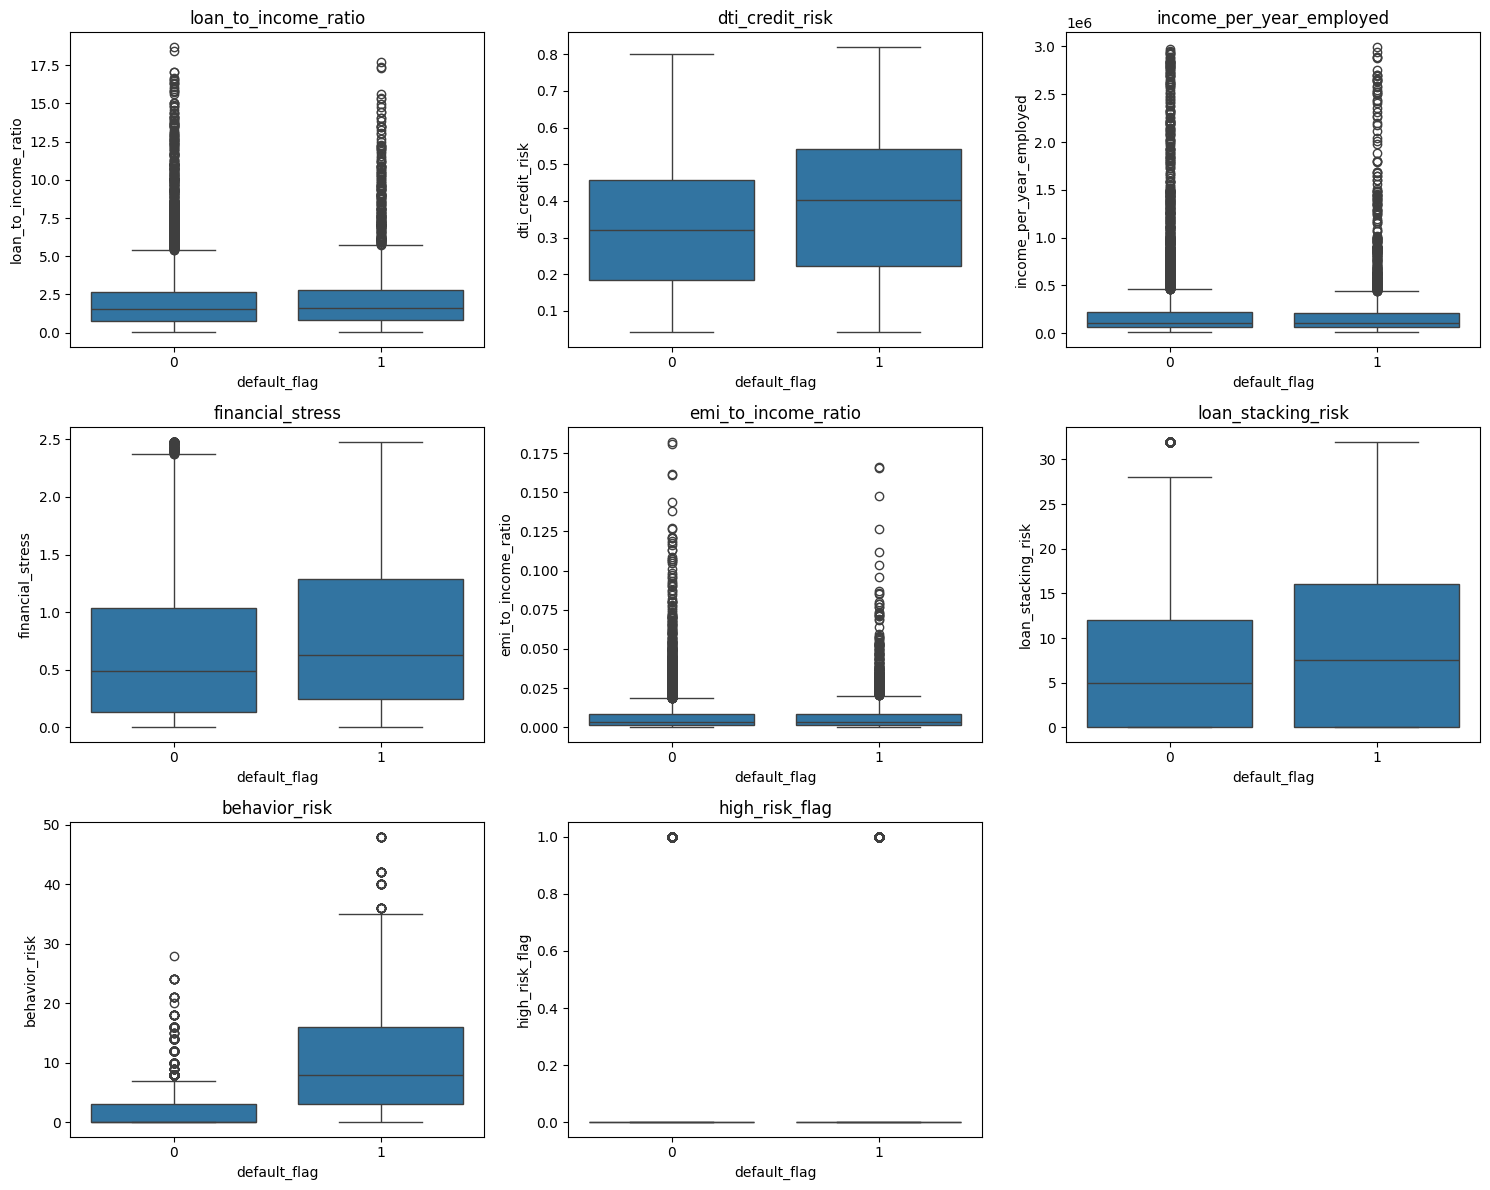

In [20]:
plt.figure(figsize=(15, 4*n_rows))

for i, col in enumerate(new_features):
    plt.subplot(n_rows, n_cols, i+1)
    sns.boxplot(data=df, x="default_flag", y=col)
    plt.title(col)

plt.tight_layout()
plt.show()

In [21]:
# 10. Default Rate vs Binned Feature

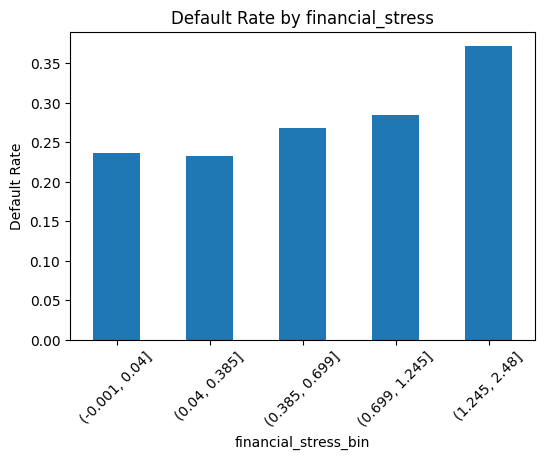

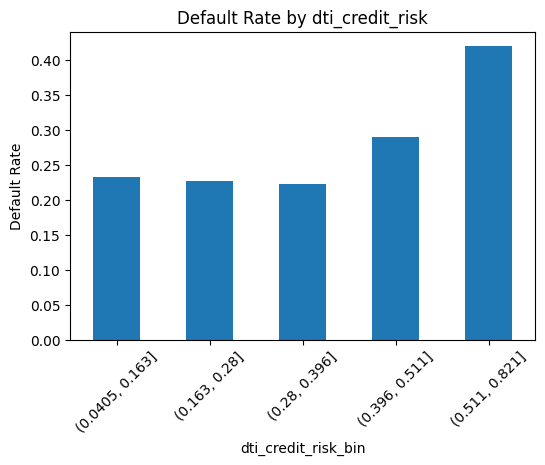

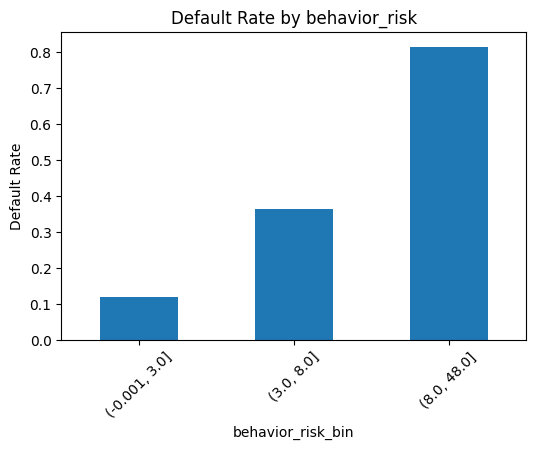

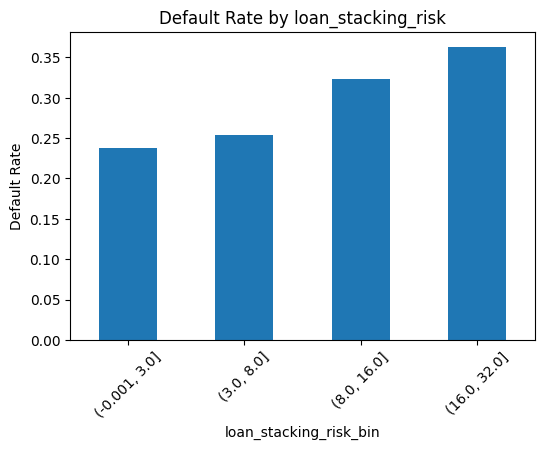

In [22]:
important_for_binning = [
    "financial_stress",
    "dti_credit_risk",
    "behavior_risk",
    "loan_stacking_risk"
]

for col in important_for_binning:
    df[col + "_bin"] = pd.qcut(df[col], q=5, duplicates="drop")
    
    rate = df.groupby(col + "_bin")["default_flag"].mean()
    
    rate.plot(kind="bar", figsize=(6,4))
    plt.title(f"Default Rate by {col}")
    plt.ylabel("Default Rate")
    plt.xticks(rotation=45)
    plt.show()

In [23]:
# 11. Feature Importance

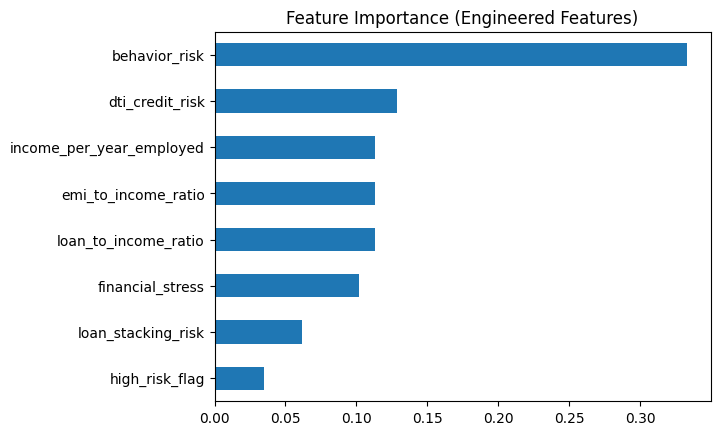

In [24]:
from sklearn.ensemble import RandomForestClassifier

X = df[new_features]
y = df["default_flag"]

model = RandomForestClassifier()
model.fit(X, y)

importance = pd.Series(model.feature_importances_, index=new_features)

importance.sort_values().plot(kind="barh")
plt.title("Feature Importance (Engineered Features)")
plt.show()

In [25]:
# 12. Pairplot

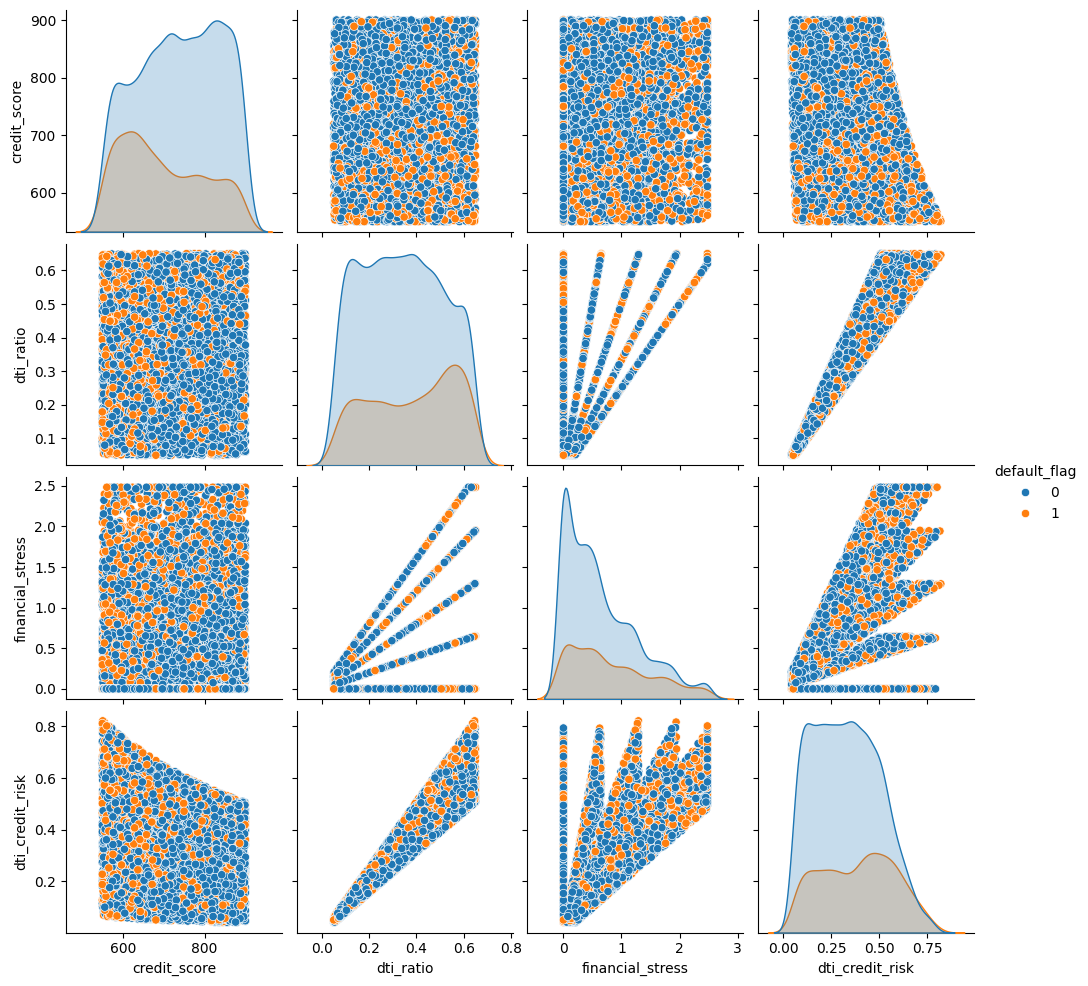

In [26]:
top_features = [
    "credit_score",
    "dti_ratio",
    "financial_stress",
    "dti_credit_risk",
    "default_flag"
]

sns.pairplot(df[top_features], hue="default_flag")
plt.show()